# Lab 22 — Optimization for NLP

[Open this notebook in Google Colab](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-22-optimization-for-nlp.ipynb)

This lab accompanies **Chapter 22: Optimization for NLP** in *The Mathematics of Natural Language Processing*.

Optimization is the engine that turns a model architecture into a trained language system. In earlier labs, we built classifiers, recurrent models, attention mechanisms, autoregressive models, retrieval systems, and evaluation tools. This lab studies the common mathematical core behind training them.

The main question is:

> Given a differentiable loss function for text data, how do we update parameters so that the model learns reliably, stably, and efficiently?

We will build most ideas from scratch with NumPy so that the mathematics is visible.

## Learning goals

By the end of this lab, you should be able to:

1. Explain an NLP training objective as an average of token-level or example-level losses.
2. Compute stable softmax cross-entropy and its gradient.
3. Verify gradients using finite differences.
4. Compare full-batch gradient descent, stochastic gradient descent, momentum, and Adam.
5. Diagnose learning-rate problems, noisy gradients, and unstable training.
6. Use weight decay, gradient clipping, and loss masks correctly.
7. Train a small text classifier and interpret optimization curves.

This notebook is designed for independent study. Read the explanations before running the code cells.

## 1. Mathematical background: what is optimized?

A supervised NLP dataset often has input text $x_i$ and target label or token $y_i$. A model with parameters $\theta$ predicts a probability distribution

$$
p_\theta(y \mid x).
$$

Training by maximum likelihood means choosing $\theta$ to make the observed targets likely. Equivalently, we minimize the negative log-likelihood:

$$
J(\theta)=\frac{1}{n}\sum_{i=1}^n -\log p_\theta(y_i\mid x_i).
$$

For a language model, each training example is a token prediction:

$$
J(\theta)=\frac{1}{T}\sum_{t=1}^T -\log p_\theta(w_t\mid w_{<t}).
$$

For a classifier with logits $z \in R^K$, softmax probabilities are

$$
p_k=\frac{\exp(z_k)}{\sum_{j=1}^K \exp(z_j)}.
$$

If the correct class is $y$, the cross-entropy loss is

$$
\ell(z,y)=-\log p_y.
$$

A key gradient identity is

$$
\frac{\partial \ell}{\partial z_k}=p_k-1_{k=y}.
$$

This simple formula is one reason softmax cross-entropy is central in NLP.

## 2. Setup

The lab uses only standard scientific Python packages. The dataset is intentionally small and transparent so that you can inspect every matrix and gradient.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7243)

print("Libraries loaded.")

Libraries loaded.


## 3. A tiny text-classification dataset

We will classify short sentences into three categories:

- `math`
- `nlp`
- `sports`

The goal is not to create a large benchmark. The goal is to make optimization visible.

In [2]:
examples = [
    ("linear algebra studies vectors matrices eigenvalues", "math"),
    ("calculus uses derivatives integrals limits", "math"),
    ("probability models random variables distributions", "math"),
    ("optimization minimizes loss using gradients", "math"),
    ("geometry studies distance angles curvature", "math"),
    ("statistics estimates parameters from samples", "math"),
    ("tokens embeddings attention transformers language", "nlp"),
    ("language models predict next tokens", "nlp"),
    ("retrieval augmented generation uses documents", "nlp"),
    ("word embeddings represent meaning as vectors", "nlp"),
    ("tokenization builds vocabularies from text", "nlp"),
    ("attention weights compare queries and keys", "nlp"),
    ("soccer players pass shoot score goals", "sports"),
    ("basketball teams defend rebound and score", "sports"),
    ("tennis players serve volley and rally", "sports"),
    ("baseball pitchers throw strikes innings", "sports"),
    ("running athletes train for races", "sports"),
    ("coaches plan strategy for the team", "sports"),
    ("matrix factorization creates vectors for documents", "math"),
    ("neural networks learn representations for text", "nlp"),
    ("the team won after scoring late", "sports"),
    ("gradient descent updates model parameters", "math"),
    ("transformers use positional encoding and attention", "nlp"),
    ("players practiced passing before the game", "sports"),
]

labels = sorted({y for _, y in examples})
label_to_id = {label: i for i, label in enumerate(labels)}
id_to_label = {i: label for label, i in label_to_id.items()}

pd.DataFrame(examples, columns=["text", "label"]).head(10)

,text,label
0,linear algebra studies vectors matrices eigenv...,math
1,calculus uses derivatives integrals limits,math
2,probability models random variables distributions,math
3,optimization minimizes loss using gradients,math
4,geometry studies distance angles curvature,math
5,statistics estimates parameters from samples,math
6,tokens embeddings attention transformers language,nlp
7,language models predict next tokens,nlp
8,retrieval augmented generation uses documents,nlp
9,word embeddings represent meaning as vectors,nlp


### Tokenization and vectorization

We use a simple bag-of-words representation. For a vocabulary of size $d$, each document becomes a vector $x \in R^d$ whose entries are token counts.

This is not a state-of-the-art representation, but it is excellent for studying optimization because the classifier is easy to differentiate.

In [3]:
def tokenize(text):
    return text.lower().split()

vocab = sorted({tok for text, _ in examples for tok in tokenize(text)})
tok_to_id = {tok: j for j, tok in enumerate(vocab)}

def vectorize(text):
    x = np.zeros(len(vocab), dtype=float)
    for tok in tokenize(text):
        if tok in tok_to_id:
            x[tok_to_id[tok]] += 1.0
    return x

X = np.vstack([vectorize(text) for text, _ in examples])
y = np.array([label_to_id[label] for _, label in examples])

# Add an intercept column to make the linear classifier more flexible.
X_aug = np.hstack([X, np.ones((X.shape[0], 1))])

print("Number of examples:", X_aug.shape[0])
print("Vocabulary size:", len(vocab))
print("Feature dimension with intercept:", X_aug.shape[1])
print("Labels:", labels)

Number of examples: 24
Vocabulary size: 105
Feature dimension with intercept: 106
Labels: ['math', 'nlp', 'sports']


## 4. Stable softmax and cross-entropy

Directly computing $\exp(z_k)$ can overflow when logits are large. The standard stable method subtracts the row maximum before exponentiating:

$$
\operatorname{softmax}(z)_k=\frac{\exp(z_k-m)}{\sum_j \exp(z_j-m)}, \quad m=\max_j z_j.
$$

This changes neither the probabilities nor the loss, because softmax is invariant under adding or subtracting the same constant from all logits.

In [4]:
def softmax_stable(Z):
    Z_shift = Z - np.max(Z, axis=1, keepdims=True)
    expZ = np.exp(Z_shift)
    return expZ / expZ.sum(axis=1, keepdims=True)

def cross_entropy_from_logits(Z, y_true):
    Z_shift = Z - np.max(Z, axis=1, keepdims=True)
    log_sum_exp = np.log(np.exp(Z_shift).sum(axis=1))
    log_probs = Z_shift - log_sum_exp[:, None]
    return -np.mean(log_probs[np.arange(len(y_true)), y_true])

Z_test = np.array([[1000.0, 1001.0, 999.0], [2.0, -1.0, 0.5]])
P_test = softmax_stable(Z_test)
print("Stable softmax probabilities:")
print(P_test)
print("Rows sum to:", P_test.sum(axis=1))
print("Cross-entropy:", cross_entropy_from_logits(Z_test, np.array([1, 0])))

Stable softmax probabilities:
[[0.2447 0.6652 0.09  ]
 [0.7856 0.0391 0.1753]]
Rows sum to: [1. 1.]
Cross-entropy: 0.32445863055076873


## 5. Softmax regression model

Our model is a linear classifier:

$$
Z = XW,
$$

where

- $X \in R^{n \times d}$ is the document-feature matrix,
- $W \in R^{d \times K}$ contains the parameters,
- $Z \in R^{n \times K}$ contains the class logits.

The loss with optional weight decay is

$$
J(W)=\frac{1}{n}\sum_{i=1}^n -\log p_W(y_i\mid x_i)+\frac{\lambda}{2}\|W_{no\ bias}\|_F^2.
$$

The gradient is

$$
\nabla_W J = \frac{1}{n}X^T(P-Y)+\lambda W_{no\ bias}.
$$

The intercept row is usually not weight-decayed.

In [5]:
def one_hot(y_true, K):
    Y = np.zeros((len(y_true), K))
    Y[np.arange(len(y_true)), y_true] = 1.0
    return Y

def loss_and_grad(W, X_batch, y_batch, weight_decay=0.0):
    n = X_batch.shape[0]
    K = W.shape[1]
    Z = X_batch @ W
    P = softmax_stable(Z)
    Y = one_hot(y_batch, K)
    loss = cross_entropy_from_logits(Z, y_batch)
    grad = X_batch.T @ (P - Y) / n
    if weight_decay > 0:
        W_decay = W.copy()
        W_decay[-1, :] = 0.0  # do not decay intercept
        loss += 0.5 * weight_decay * np.sum(W_decay * W_decay)
        grad += weight_decay * W_decay
    return loss, grad, P

d, K = X_aug.shape[1], len(labels)
W0 = rng.normal(0, 0.01, size=(d, K))
loss0, grad0, P0 = loss_and_grad(W0, X_aug, y)
print("Initial loss:", loss0)
print("Gradient shape:", grad0.shape)
print("First example probabilities:", P0[0])

Initial loss: 1.1012827500583713
Gradient shape: (106, 3)
First example probabilities: [0.3243 0.3398 0.3359]


## 6. Gradient checking

Before trusting a gradient formula, we can compare it to a finite-difference approximation.

For one parameter $W_{ab}$,

$$
\frac{\partial J}{\partial W_{ab}} \approx \frac{J(W+\epsilon E_{ab})-J(W-\epsilon E_{ab})}{2\epsilon}.
$$

This is slower than backpropagation, but useful for debugging small models.

In [6]:
def finite_difference_check(W, X_data, y_data, num_checks=8, eps=1e-5):
    loss, grad, _ = loss_and_grad(W, X_data, y_data)
    rows = rng.integers(0, W.shape[0], size=num_checks)
    cols = rng.integers(0, W.shape[1], size=num_checks)
    records = []
    for a, b in zip(rows, cols):
        E = np.zeros_like(W)
        E[a, b] = 1.0
        loss_plus, _, _ = loss_and_grad(W + eps * E, X_data, y_data)
        loss_minus, _, _ = loss_and_grad(W - eps * E, X_data, y_data)
        numeric = (loss_plus - loss_minus) / (2 * eps)
        analytic = grad[a, b]
        records.append({
            "row": int(a),
            "col": int(b),
            "analytic": analytic,
            "numeric": numeric,
            "absolute_error": abs(analytic - numeric)
        })
    return pd.DataFrame(records)

check_df = finite_difference_check(W0, X_aug, y)
check_df

,row,col,analytic,numeric,absolute_error
0,48,2,0.013738,0.013738,1.867947e-12
1,71,2,0.014181,0.014181,3.713698e-12
2,70,2,0.013751,0.013751,1.618063e-13
3,88,0,0.040805,0.040805,5.830801e-12
4,75,0,0.027974,0.027974,4.198340e-12
5,102,2,0.013356,0.013356,7.157584e-12
6,49,1,0.013656,0.013656,4.465095e-12
7,12,1,0.013878,0.013878,6.521894e-12


The absolute errors should be small, often around $10^{-10}$ to $10^{-7}$ for this example. Larger errors usually indicate a wrong sign, missing average factor, or mismatch between the loss and gradient.

## 7. Full-batch gradient descent

Gradient descent updates parameters by

$$
W_{t+1}=W_t-\eta \nabla J(W_t),
$$

where $\eta$ is the learning rate.

The learning rate is not a minor detail. If it is too small, training is slow. If it is too large, the loss may oscillate or diverge.

In [7]:
def accuracy(W, X_data, y_data):
    pred = np.argmax(X_data @ W, axis=1)
    return np.mean(pred == y_data)

def train_full_batch(lr=0.3, steps=120, weight_decay=0.0, seed=0):
    local_rng = np.random.default_rng(seed)
    W = local_rng.normal(0, 0.01, size=(d, K))
    history = []
    for step in range(steps + 1):
        loss, grad, _ = loss_and_grad(W, X_aug, y, weight_decay=weight_decay)
        acc = accuracy(W, X_aug, y)
        history.append({"step": step, "loss": loss, "accuracy": acc, "grad_norm": np.linalg.norm(grad)})
        if step < steps:
            W = W - lr * grad
    return W, pd.DataFrame(history)

W_gd, hist_gd = train_full_batch(lr=0.4, steps=120, seed=1)
print(hist_gd.tail())
print("Final training accuracy:", accuracy(W_gd, X_aug, y))

     step      loss  accuracy  grad_norm
116   116  0.065991       1.0   0.038841
117   117  0.065390       1.0   0.038499
118   118  0.064800       1.0   0.038163
119   119  0.064220       1.0   0.037833
120   120  0.063650       1.0   0.037508
Final training accuracy: 1.0


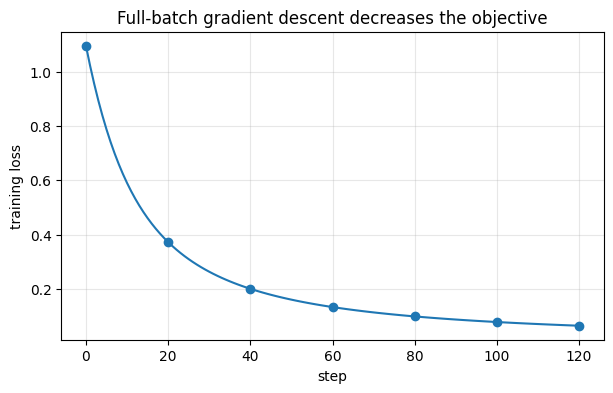

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(hist_gd["step"], hist_gd["loss"], marker="o", markevery=20)
plt.xlabel("step")
plt.ylabel("training loss")
plt.title("Full-batch gradient descent decreases the objective")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Learning-rate experiment

We now train the same model with several learning rates.

For convex softmax regression, a reasonable learning rate should decrease the loss smoothly. Too large a learning rate may make the loss jump or plateau.

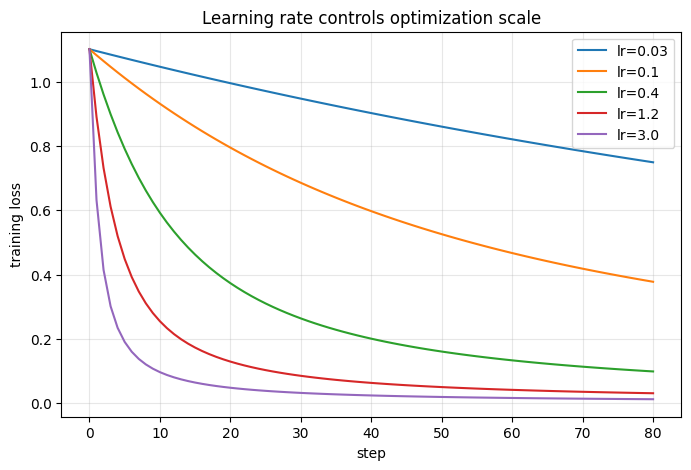

,learning_rate,final_loss,final_accuracy
0,0.03,0.749655,1.0
1,0.10,0.377417,1.0
2,0.40,0.098017,1.0
3,1.20,0.030100,1.0
4,3.00,0.011471,1.0


In [9]:
lrs = [0.03, 0.1, 0.4, 1.2, 3.0]
lr_histories = {}
for lr in lrs:
    _, hist = train_full_batch(lr=lr, steps=80, seed=2)
    lr_histories[lr] = hist

plt.figure(figsize=(8, 5))
for lr, hist in lr_histories.items():
    plt.plot(hist["step"], hist["loss"], label=f"lr={lr}")
plt.xlabel("step")
plt.ylabel("training loss")
plt.title("Learning rate controls optimization scale")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

summary = pd.DataFrame({
    "learning_rate": lrs,
    "final_loss": [lr_histories[lr]["loss"].iloc[-1] for lr in lrs],
    "final_accuracy": [lr_histories[lr]["accuracy"].iloc[-1] for lr in lrs]
})
summary

## 9. Stochastic gradients and mini-batches

For large NLP datasets, full-batch gradients are too expensive. Instead, we approximate the full gradient using a mini-batch:

$$
g_t=\nabla J_{B_t}(W_t).
$$

The stochastic gradient is noisy, but it is much cheaper and can help exploration.

In [10]:
def train_minibatch_sgd(lr=0.2, epochs=50, batch_size=6, seed=0, weight_decay=0.0):
    local_rng = np.random.default_rng(seed)
    W = local_rng.normal(0, 0.01, size=(d, K))
    n = X_aug.shape[0]
    history = []
    for epoch in range(epochs + 1):
        full_loss, full_grad, _ = loss_and_grad(W, X_aug, y, weight_decay=weight_decay)
        history.append({
            "epoch": epoch,
            "loss": full_loss,
            "accuracy": accuracy(W, X_aug, y),
            "full_grad_norm": np.linalg.norm(full_grad)
        })
        if epoch == epochs:
            break
        order = local_rng.permutation(n)
        for start in range(0, n, batch_size):
            idx = order[start:start+batch_size]
            _, grad, _ = loss_and_grad(W, X_aug[idx], y[idx], weight_decay=weight_decay)
            W = W - lr * grad
    return W, pd.DataFrame(history)

W_sgd, hist_sgd = train_minibatch_sgd(lr=0.2, epochs=80, batch_size=4, seed=3)
print(hist_sgd.tail())

    epoch      loss  accuracy  full_grad_norm
76     76  0.031662       1.0        0.018967
77     77  0.031233       1.0        0.018714
78     78  0.030816       1.0        0.018468
79     79  0.030409       1.0        0.018227
80     80  0.030012       1.0        0.017993


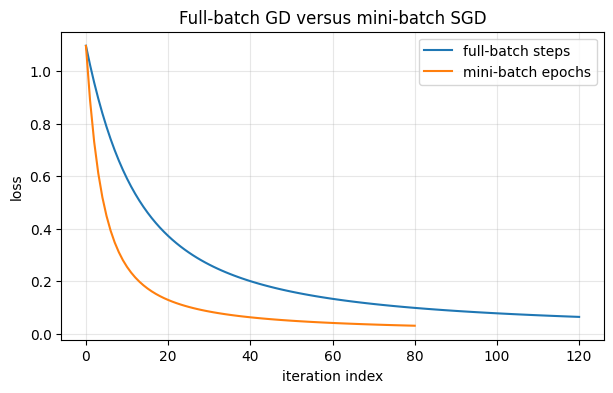

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(hist_gd["step"], hist_gd["loss"], label="full-batch steps")
plt.plot(hist_sgd["epoch"], hist_sgd["loss"], label="mini-batch epochs")
plt.xlabel("iteration index")
plt.ylabel("loss")
plt.title("Full-batch GD versus mini-batch SGD")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Measuring gradient noise

At a fixed parameter value, different mini-batches give different gradients. We can measure this variation.

In [12]:
def sample_minibatch_grad_norms(W, batch_size=4, samples=100, seed=4):
    local_rng = np.random.default_rng(seed)
    norms = []
    cosine_to_full = []
    _, full_grad, _ = loss_and_grad(W, X_aug, y)
    full_flat = full_grad.ravel()
    full_norm = np.linalg.norm(full_flat)
    for _ in range(samples):
        idx = local_rng.choice(len(y), size=batch_size, replace=False)
        _, g, _ = loss_and_grad(W, X_aug[idx], y[idx])
        g_flat = g.ravel()
        norms.append(np.linalg.norm(g_flat))
        cosine_to_full.append(np.dot(g_flat, full_flat) / (np.linalg.norm(g_flat) * full_norm + 1e-12))
    return pd.DataFrame({"grad_norm": norms, "cosine_to_full_gradient": cosine_to_full})

noise_df = sample_minibatch_grad_norms(W0, batch_size=4, samples=200)
noise_df.describe()

,grad_norm,cosine_to_full_gradient
count,200.000000,200.000000
mean,1.040374,0.413162
std,0.069400,0.051029
min,0.933199,0.278738
25%,0.980112,0.377063
50%,1.032109,0.417090
75%,1.098324,0.450227
max,1.214963,0.539520


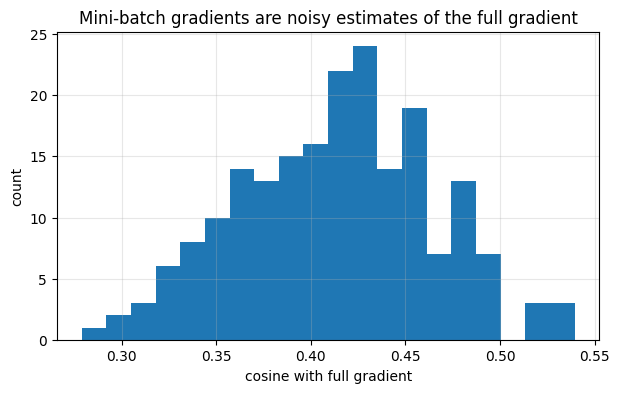

In [13]:
plt.figure(figsize=(7, 4))
plt.hist(noise_df["cosine_to_full_gradient"], bins=20)
plt.xlabel("cosine with full gradient")
plt.ylabel("count")
plt.title("Mini-batch gradients are noisy estimates of the full gradient")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Momentum

Momentum uses a velocity vector:

$$
v_{t+1}=\mu v_t + g_t, \qquad W_{t+1}=W_t-\eta v_{t+1}.
$$

Intuition: if gradients repeatedly point in similar directions, momentum accumulates speed. If gradients alternate directions, momentum smooths them.

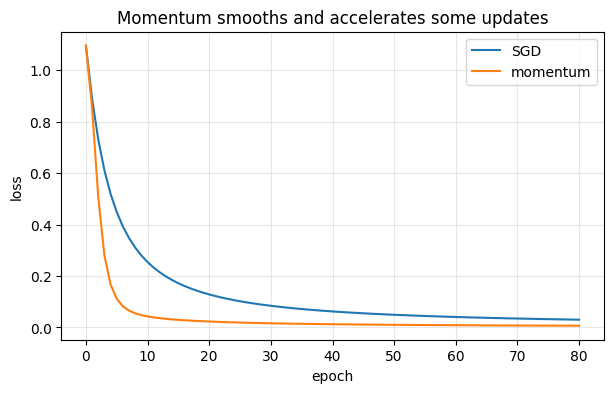

,method,final_loss,final_accuracy
0,SGD,0.030012,1.0
1,Momentum,0.006529,1.0


In [14]:
def train_momentum(lr=0.08, momentum=0.9, epochs=80, batch_size=4, seed=0):
    local_rng = np.random.default_rng(seed)
    W = local_rng.normal(0, 0.01, size=(d, K))
    V = np.zeros_like(W)
    n = X_aug.shape[0]
    history = []
    for epoch in range(epochs + 1):
        loss, full_grad, _ = loss_and_grad(W, X_aug, y)
        history.append({"epoch": epoch, "loss": loss, "accuracy": accuracy(W, X_aug, y), "grad_norm": np.linalg.norm(full_grad)})
        if epoch == epochs:
            break
        order = local_rng.permutation(n)
        for start in range(0, n, batch_size):
            idx = order[start:start+batch_size]
            _, grad, _ = loss_and_grad(W, X_aug[idx], y[idx])
            V = momentum * V + grad
            W = W - lr * V
    return W, pd.DataFrame(history)

W_mom, hist_mom = train_momentum(lr=0.08, momentum=0.9, epochs=80, batch_size=4, seed=3)

plt.figure(figsize=(7, 4))
plt.plot(hist_sgd["epoch"], hist_sgd["loss"], label="SGD")
plt.plot(hist_mom["epoch"], hist_mom["loss"], label="momentum")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Momentum smooths and accelerates some updates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({
    "method": ["SGD", "Momentum"],
    "final_loss": [hist_sgd["loss"].iloc[-1], hist_mom["loss"].iloc[-1]],
    "final_accuracy": [hist_sgd["accuracy"].iloc[-1], hist_mom["accuracy"].iloc[-1]]
})

## 11. Adam and adaptive learning rates

Adam keeps exponential moving averages of gradients and squared gradients:

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,
$$

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2.
$$

After bias correction,

$$
W_{t+1}=W_t-\eta \frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}.
$$

Adam is widely used for neural NLP because it adapts the step size coordinate by coordinate.

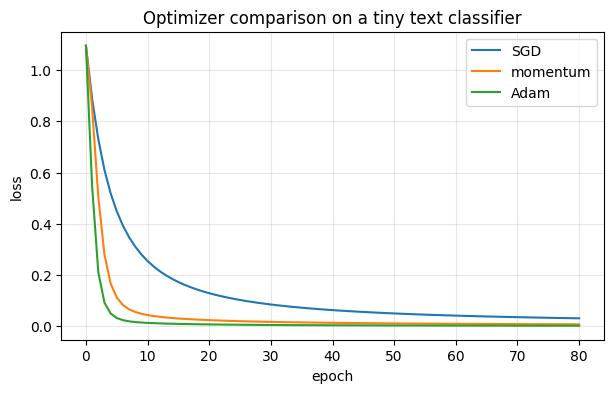

,method,final_loss,final_accuracy
0,SGD,0.030012,1.0
1,Momentum,0.006529,1.0
2,Adam,0.001050,1.0


In [15]:
def train_adam(lr=0.08, epochs=80, batch_size=4, seed=0, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0, adamw=False):
    local_rng = np.random.default_rng(seed)
    W = local_rng.normal(0, 0.01, size=(d, K))
    M = np.zeros_like(W)
    V = np.zeros_like(W)
    t = 0
    n = X_aug.shape[0]
    history = []
    for epoch in range(epochs + 1):
        loss, full_grad, _ = loss_and_grad(W, X_aug, y, weight_decay=0.0 if adamw else weight_decay)
        # For AdamW, report the data loss plus a diagnostic penalty, but apply decoupled decay in the update.
        report_loss = loss + (0.5 * weight_decay * np.sum(W[:-1] * W[:-1]) if adamw and weight_decay > 0 else 0.0)
        history.append({"epoch": epoch, "loss": report_loss, "accuracy": accuracy(W, X_aug, y), "weight_norm": np.linalg.norm(W[:-1])})
        if epoch == epochs:
            break
        order = local_rng.permutation(n)
        for start in range(0, n, batch_size):
            idx = order[start:start+batch_size]
            _, grad, _ = loss_and_grad(W, X_aug[idx], y[idx], weight_decay=0.0 if adamw else weight_decay)
            t += 1
            M = beta1 * M + (1 - beta1) * grad
            V = beta2 * V + (1 - beta2) * (grad * grad)
            M_hat = M / (1 - beta1 ** t)
            V_hat = V / (1 - beta2 ** t)
            if adamw and weight_decay > 0:
                decay_mask = np.ones_like(W)
                decay_mask[-1, :] = 0.0
                W = W * (1 - lr * weight_decay * decay_mask)
            W = W - lr * M_hat / (np.sqrt(V_hat) + eps)
    return W, pd.DataFrame(history)

W_adam, hist_adam = train_adam(lr=0.05, epochs=80, batch_size=4, seed=3)

plt.figure(figsize=(7, 4))
plt.plot(hist_sgd["epoch"], hist_sgd["loss"], label="SGD")
plt.plot(hist_mom["epoch"], hist_mom["loss"], label="momentum")
plt.plot(hist_adam["epoch"], hist_adam["loss"], label="Adam")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Optimizer comparison on a tiny text classifier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({
    "method": ["SGD", "Momentum", "Adam"],
    "final_loss": [hist_sgd["loss"].iloc[-1], hist_mom["loss"].iloc[-1], hist_adam["loss"].iloc[-1]],
    "final_accuracy": [hist_sgd["accuracy"].iloc[-1], hist_mom["accuracy"].iloc[-1], hist_adam["accuracy"].iloc[-1]]
})

## 12. AdamW and weight decay

Weight decay discourages overly large parameters. For Adam, modern practice often uses **decoupled weight decay**, called AdamW:

$$
W \leftarrow (1-\eta\lambda)W - \eta\cdot \text{AdamStep}.
$$

This separates the shrinkage step from the adaptive-gradient step.

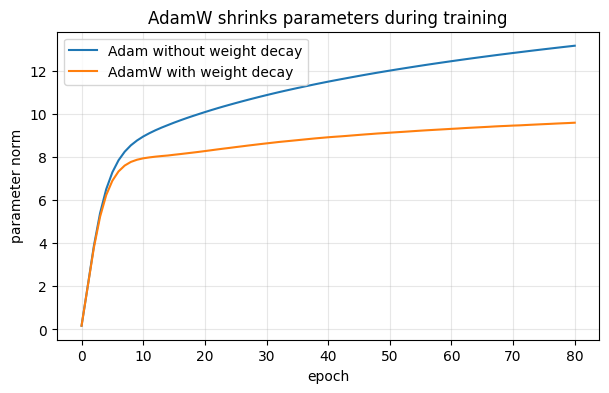

,method,final_loss,final_accuracy,final_weight_norm
0,Adam,0.001028,1.0,13.192162
1,AdamW,3.703675,1.0,9.612105


In [16]:
W_no_decay, hist_no_decay = train_adam(lr=0.05, epochs=80, batch_size=4, seed=5, weight_decay=0.0, adamw=True)
W_decay, hist_decay = train_adam(lr=0.05, epochs=80, batch_size=4, seed=5, weight_decay=0.08, adamw=True)

plt.figure(figsize=(7, 4))
plt.plot(hist_no_decay["epoch"], hist_no_decay["weight_norm"], label="Adam without weight decay")
plt.plot(hist_decay["epoch"], hist_decay["weight_norm"], label="AdamW with weight decay")
plt.xlabel("epoch")
plt.ylabel("parameter norm")
plt.title("AdamW shrinks parameters during training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({
    "method": ["Adam", "AdamW"],
    "final_loss": [hist_no_decay["loss"].iloc[-1], hist_decay["loss"].iloc[-1]],
    "final_accuracy": [hist_no_decay["accuracy"].iloc[-1], hist_decay["accuracy"].iloc[-1]],
    "final_weight_norm": [hist_no_decay["weight_norm"].iloc[-1], hist_decay["weight_norm"].iloc[-1]]
})

## 13. Gradient clipping

Large gradients can make training unstable. Gradient clipping replaces a gradient $g$ by

$$
\tilde g = g \cdot \min\left(1, \frac{c}{\|g\|}\right),
$$

where $c$ is the clipping threshold.

This is especially important in recurrent models and deep sequence models.

In [17]:
def clip_by_norm(g, max_norm):
    norm = np.linalg.norm(g)
    if norm > max_norm:
        return g * (max_norm / (norm + 1e-12)), norm
    return g.copy(), norm

# Create an artificial extreme example by scaling some features.
X_bad = X_aug.copy()
X_bad[:, :5] *= 100.0
W_bad = rng.normal(0, 0.01, size=(d, K))
loss_bad, grad_bad, _ = loss_and_grad(W_bad, X_bad, y)
clipped_grad, original_norm = clip_by_norm(grad_bad, max_norm=5.0)

print("Loss on scaled features:", loss_bad)
print("Original gradient norm:", original_norm)
print("Clipped gradient norm:", np.linalg.norm(clipped_grad))

Loss on scaled features: 1.1694975015155593
Original gradient norm: 12.470338862022064
Clipped gradient norm: 4.999999999999599


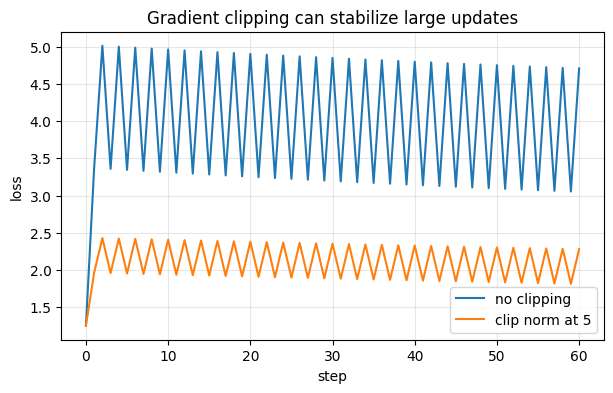

In [18]:
def train_with_optional_clipping(X_data, y_data, lr=0.05, steps=60, clip_norm=None, seed=6):
    local_rng = np.random.default_rng(seed)
    W = local_rng.normal(0, 0.01, size=(X_data.shape[1], K))
    history = []
    for step in range(steps + 1):
        loss, grad, _ = loss_and_grad(W, X_data, y_data)
        grad_norm_before = np.linalg.norm(grad)
        if clip_norm is not None:
            grad, _ = clip_by_norm(grad, clip_norm)
        history.append({
            "step": step,
            "loss": loss,
            "accuracy": accuracy(W, X_data, y_data),
            "grad_norm_before": grad_norm_before,
            "grad_norm_after": np.linalg.norm(grad)
        })
        if step < steps:
            W = W - lr * grad
    return W, pd.DataFrame(history)

_, hist_unclipped = train_with_optional_clipping(X_bad, y, lr=0.05, steps=60, clip_norm=None)
_, hist_clipped = train_with_optional_clipping(X_bad, y, lr=0.05, steps=60, clip_norm=5.0)

plt.figure(figsize=(7, 4))
plt.plot(hist_unclipped["step"], hist_unclipped["loss"], label="no clipping")
plt.plot(hist_clipped["step"], hist_clipped["loss"], label="clip norm at 5")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Gradient clipping can stabilize large updates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 14. Optimization on a quadratic surface

A quadratic objective is a simple laboratory for optimizer dynamics:

$$
f(w)=\frac{1}{2}w^TAw.
$$

If $A$ has very different eigenvalues, the surface is narrow in one direction and flat in another. This resembles ill-conditioning in neural-network training.

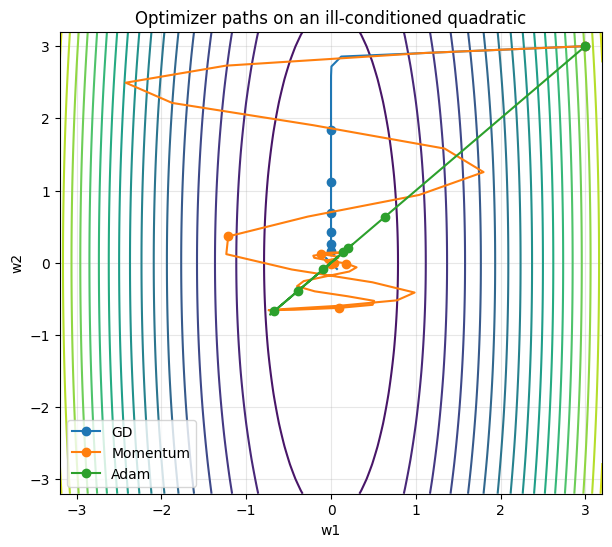

,GD,Momentum,Adam
final quadratic loss,0.004917,0.000202,0.034641


In [19]:
A = np.array([[8.0, 0.0], [0.0, 0.4]])

def quad_loss(w):
    return 0.5 * float(w.T @ A @ w)

def quad_grad(w):
    return A @ w

def path_gd(w0, lr=0.12, steps=60):
    w = w0.copy()
    path = [w.copy()]
    for _ in range(steps):
        w = w - lr * quad_grad(w)
        path.append(w.copy())
    return np.array(path)

def path_momentum(w0, lr=0.08, mu=0.85, steps=60):
    w = w0.copy()
    v = np.zeros_like(w)
    path = [w.copy()]
    for _ in range(steps):
        v = mu * v + quad_grad(w)
        w = w - lr * v
        path.append(w.copy())
    return np.array(path)

def path_adam(w0, lr=0.25, beta1=0.9, beta2=0.99, steps=60, eps=1e-8):
    w = w0.copy()
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    path = [w.copy()]
    for t in range(1, steps + 1):
        g = quad_grad(w)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g * g)
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
        w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(w.copy())
    return np.array(path)

w_start = np.array([3.0, 3.0])
paths = {
    "GD": path_gd(w_start),
    "Momentum": path_momentum(w_start),
    "Adam": path_adam(w_start),
}

xx = np.linspace(-3.2, 3.2, 100)
yy = np.linspace(-3.2, 3.2, 100)
XX, YY = np.meshgrid(xx, yy)
ZZ = 0.5 * (A[0,0] * XX**2 + A[1,1] * YY**2)

plt.figure(figsize=(7, 6))
plt.contour(XX, YY, ZZ, levels=20)
for name, path in paths.items():
    plt.plot(path[:, 0], path[:, 1], marker="o", markevery=10, label=name)
plt.scatter([0], [0], marker="x", s=80)
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Optimizer paths on an ill-conditioned quadratic")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({name: [quad_loss(path[-1])] for name, path in paths.items()}, index=["final quadratic loss"])

## 15. Loss masks for padded sequences

NLP batches often contain sequences with different lengths. Padding tokens should not contribute to the loss.

Suppose a batch has token losses $L_{bt}$ and a mask $M_{bt}\in\{0,1\}$. The masked loss is

$$
\frac{\sum_{b,t} M_{bt}L_{bt}}{\sum_{b,t} M_{bt}}.
$$

This is used in language-model training, sequence tagging, and supervised fine-tuning.

In [20]:
# Four sequences padded to length 6. 0 means padding for this example.
token_losses = np.array([
    [0.2, 0.5, 0.7, 0.0, 0.0, 0.0],
    [1.1, 0.9, 0.8, 0.6, 0.0, 0.0],
    [0.4, 0.3, 0.2, 0.5, 0.6, 0.0],
    [0.9, 0.7, 0.4, 0.2, 0.1, 0.3],
])
mask = np.array([
    [1, 1, 1, 0, 0, 0],
    [1, 1, 1, 1, 0, 0],
    [1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1],
], dtype=float)

unmasked_mean = token_losses.mean()
masked_mean = (token_losses * mask).sum() / mask.sum()
print("Unmasked mean loss:", unmasked_mean)
print("Masked mean loss:", masked_mean)
print("Number of real tokens:", int(mask.sum()))

Unmasked mean loss: 0.39166666666666666
Masked mean loss: 0.5222222222222223
Number of real tokens: 18


## 16. Inspecting learned parameters

After optimization, the model should associate certain words with certain classes. We can inspect the largest weights for each class.

In [21]:
def top_weights(W, class_id, top_n=8):
    # Exclude intercept row.
    weights = W[:-1, class_id]
    top_idx = np.argsort(weights)[::-1][:top_n]
    return pd.DataFrame({
        "token": [vocab[j] for j in top_idx],
        "weight": weights[top_idx]
    })

for class_id, label in id_to_label.items():
    print("\nTop tokens for class:", label)
    display(top_weights(W_adam, class_id, top_n=8))


Top tokens for class: math


,token,weight
0,parameters,1.075922
1,factorization,0.946583
2,matrix,0.943902
3,studies,0.938614
4,creates,0.938528
5,integrals,0.875038
6,limits,0.867745
7,derivatives,0.857922



Top tokens for class: nlp


,token,weight
0,text,1.093424
1,language,0.978283
2,tokens,0.969959
3,augmented,0.935784
4,retrieval,0.928445
5,generation,0.917842
6,attention,0.890631
7,embeddings,0.836920



Top tokens for class: sports


,token,weight
0,players,1.013977
1,the,0.909465
2,score,0.878712
3,races,0.839380
4,running,0.821484
5,train,0.820952
6,athletes,0.820672
7,baseball,0.767661


## 17. Test the classifier on new sentences

Optimization should produce parameters that generalize beyond the training examples. With such a small dataset, predictions are only illustrative.

In [22]:
def predict_texts(W, texts):
    X_new = np.vstack([vectorize(text) for text in texts])
    X_new_aug = np.hstack([X_new, np.ones((X_new.shape[0], 1))])
    probs = softmax_stable(X_new_aug @ W)
    rows = []
    for text, p in zip(texts, probs):
        pred_id = int(np.argmax(p))
        row = {"text": text, "prediction": id_to_label[pred_id], "confidence": float(p[pred_id])}
        for k, label in id_to_label.items():
            row[f"p_{label}"] = float(p[k])
        rows.append(row)
    return pd.DataFrame(rows)

new_texts = [
    "attention models use keys and queries",
    "players score goals after passing",
    "gradients minimize matrix loss",
    "documents use vectors and probability",
    "the coach trained the team",
]

predict_texts(W_adam, new_texts)

,text,prediction,confidence,p_math,p_nlp,p_sports
0,attention models use keys and queries,nlp,0.997684,0.001566,0.997684,0.000750
1,players score goals after passing,sports,0.998298,0.000977,0.000725,0.998298
2,gradients minimize matrix loss,math,0.986209,0.986209,0.005842,0.007949
3,documents use vectors and probability,nlp,0.569955,0.414953,0.569955,0.015092
4,the coach trained the team,sports,0.984604,0.008148,0.007248,0.984604


## 18. AI-assisted optimization audit prompts

Use these prompts with an AI assistant, then verify the answer mathematically or by experiment.

**Prompt 1. Gradient audit**

> I have logits $Z=XW$ and cross-entropy loss. Derive the gradient with respect to $W$ and explain each matrix shape.

**Prompt 2. Stability audit**

> My softmax cross-entropy sometimes returns `nan`. List likely numerical causes and show a stable log-sum-exp implementation.

**Prompt 3. Optimizer diagnosis**

> My NLP model's training loss decreases but validation loss increases. Give optimization-related and data-related explanations, and suggest diagnostics.

**Prompt 4. Masking audit**

> I am training on padded sequences. How should I compute average token-level cross-entropy so that padding tokens do not affect the loss?

AI tools are useful for debugging explanations, but they can confuse Adam, AdamW, L2 regularization, and loss masking. Always check formulas and shapes.

## 19. Exercises

### Exercise 1 — Derive the softmax gradient

For $p=\operatorname{softmax}(z)$ and loss $\ell(z,y)=-\log p_y$, show that

$$
\frac{\partial \ell}{\partial z_k}=p_k-1_{k=y}.
$$

### Exercise 2 — Learning-rate sensitivity

Rerun the learning-rate experiment with at least three additional learning rates. Which values train quickly without instability?

### Exercise 3 — Batch size and gradient noise

Change `batch_size` in the mini-batch gradient-noise experiment. What happens to the distribution of cosine similarities with the full gradient?

### Exercise 4 — Implement RMSProp

Implement RMSProp and compare it with SGD, momentum, and Adam on the tiny text classifier.

### Exercise 5 — Clipping threshold

Try clipping thresholds $0.5$, $1$, $5$, and $20$ on the scaled-feature example. Which thresholds help? Which thresholds slow training too much?

### Exercise 6 — Loss masking

Create a new padded batch of token losses. Compute both masked and unmasked means. Explain why the unmasked mean is biased.

## 20. Mini-project — Optimizer comparison for text classification

Design a small experiment comparing at least four optimization methods for a text classifier.

Your project should include:

1. A small text dataset with at least three classes.
2. A clear vectorization method.
3. A softmax regression or small neural-network model.
4. Training curves for each optimizer.
5. Final accuracy and loss table.
6. A short discussion of stability, speed, and generalization.

Suggested optimizer set:

- full-batch gradient descent,
- mini-batch SGD,
- momentum,
- RMSProp or Adam,
- AdamW with weight decay.

Suggested diagnostic plots:

- training loss versus step,
- gradient norm versus step,
- parameter norm versus step,
- validation loss versus training loss.

## 21. What to remember

Optimization is not only a technical detail. In NLP, it shapes what a model can learn and whether training succeeds at all.

Key points:

- Cross-entropy plus softmax has a simple gradient: probability minus one-hot target.
- Stable log-sum-exp is essential for reliable training.
- Mini-batch gradients are noisy approximations to full gradients.
- Learning rate is a scale parameter; poor choices can dominate all other design decisions.
- Momentum smooths update directions.
- Adam adapts coordinate-wise learning rates.
- AdamW decouples weight decay from adaptive gradients.
- Gradient clipping controls rare but dangerous large updates.
- Loss masks are necessary for padded sequence batches.
- Every optimizer should be monitored with loss curves, gradient norms, and validation metrics.